## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 2. Data Loading

In [2]:
df = pd.read_csv(r"C:\Users\narla\Downloads\customer churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Understanding & Data Quality

#### 3.1. Initial Data Profiling

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### 3.2. Renaming Columns

In [5]:
df.columns = [
    'customer_id',
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'tenure',
    'phone_service',
    'multiple_lines',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'contract',
    'paperless_billing',
    'payment_method',
    'monthly_charges',
    'total_charges',
    'churn'
]

#### 3.3. Validating Categorical Values Of 'senior_citizen'

In [6]:
def categorical_profile(df, categorical_cols):
    for col in categorical_cols:
        print(f"\n-----------------------------------------------")
        print(df[col].value_counts(dropna=False))

In [7]:
categorical_cols = ['senior_citizen']

categorical_profile(df, categorical_cols)


-----------------------------------------------
senior_citizen
0    5901
1    1142
Name: count, dtype: int64


#### 3.4. Changing 'senior_citizen' col Values

In [8]:
df['senior_citizen'] = df['senior_citizen'].map({
    0: 'No',
    1: 'Yes'
})

In [9]:
df['senior_citizen'].value_counts(dropna=False)

senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64

#### 3.5. Converting Data Types

In [10]:
#senior_citizen
df['senior_citizen'] = df['senior_citizen'].astype('object')

#total_charges
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

#### 3.6. Automated Data-Quality Check

In [11]:
def profile_data(df):
    profile = pd.DataFrame({
        "column": df.columns,
        "data_type": df.dtypes.astype(str).values,
        "missing_count": df.isnull().sum().values,
        "missing_pct": (df.isnull().mean().values * 100).round(2),
        "unique_values": df.nunique().values
    })
    
    return profile

In [12]:
profile=profile_data(df)
profile

,column,data_type,missing_count,missing_pct,unique_values
0,customer_id,object,0,0.00,7043
1,gender,object,0,0.00,2
2,senior_citizen,object,0,0.00,2
3,partner,object,0,0.00,2
4,dependents,object,0,0.00,2
5,tenure,int64,0,0.00,73
6,phone_service,object,0,0.00,2
7,multiple_lines,object,0,0.00,3
8,internet_service,object,0,0.00,3
9,online_security,object,0,0.00,3


#### 3.7. Investigating those 11 Missing Values

In [13]:
df[df['total_charges'].isna()][
    ['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'churn']
]

,customer_id,tenure,monthly_charges,total_charges,churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


#### 3.8. Handling Missing Values 

In [14]:
df.loc[
    (df['tenure'] == 0) & (df['total_charges'].isna()),
    'total_charges'
] = 0

In [15]:
print("Missing total_charges:", df['total_charges'].isna().sum())

Missing total_charges: 0


In [16]:
df[df['tenure'] == 0][
    ['customer_id', 'tenure', 'monthly_charges', 'total_charges', 'churn']
]

,customer_id,tenure,monthly_charges,total_charges,churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


#### 3.9. Duplicate Check

In [17]:
int(df.duplicated().sum())

0

#### 3.10. Validating Remaining Categorical Values

In [18]:
categorical_cols = [
    "contract",
    "payment_method",
    "internet_service",
    'multiple_lines',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
]

categorical_profile(df, categorical_cols)


-----------------------------------------------
contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

-----------------------------------------------
payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

-----------------------------------------------
internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

-----------------------------------------------
multiple_lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

-----------------------------------------------
online_security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

-----------------------------------------------
online_backup
No                     3088
Yes                    2429
No interne

#### 3.11. Numerical Validation

In [19]:
int((df["monthly_charges"] < 0).sum())

0

In [20]:
int((df["tenure"] < 0).sum())

0

In [21]:
int((df["total_charges"] < 0).sum())

0

## 4. Feature Engineering

#### 4.1. Creating Tenure Groups

In [22]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

#### 4.2. Creating Churn Flag

In [23]:
df["churn_flag"] = (
    df["churn"]
    .map({"Yes": 1, "No": 0})
)

## 5. Business KPIs

#### 5.1. Core Customer KPIs

In [24]:
total_customers = df["customer_id"].nunique()

churned_customers = int(
    df["churn_flag"].sum()
)

churn_rate = (
    churned_customers
    / total_customers
) * 100

avg_monthly_charges = (
    df["monthly_charges"].mean()
)

avg_tenure = (
    df["tenure"].mean()
)

monthly_charges_from_churned_customers = (
    df.loc[
        df["churn_flag"] == 1,
        "monthly_charges"
    ].sum()
)

In [25]:
kpis = {
    "Total_Customers": total_customers,
    "Churned_Customers": churned_customers,
    "Churn_Rate_%": round(churn_rate, 2),
    "Average_Monthly_Charges": round(avg_monthly_charges, 2),
    "Average_Tenure": round(avg_tenure, 2),
    "Monthly_Charges_from_Churned_Customers":
        round(monthly_charges_from_churned_customers, 2)
}

KPIs = pd.DataFrame([kpis])

KPIs

,Total_Customers,Churned_Customers,Churn_Rate_%,Average_Monthly_Charges,Average_Tenure,Monthly_Charges_from_Churned_Customers
0,7043,1869,26.54,64.76,32.37,139130.85


## 6. Exploratory Data Analysis

#### 6.1. Descriptive Statistics

In [26]:
df["monthly_charges"].describe().round(2)

count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: monthly_charges, dtype: float64

In [27]:
df["total_charges"].describe().round(2)

count    7043.00
mean     2279.73
std      2266.79
min         0.00
25%       398.55
50%      1394.55
75%      3786.60
max      8684.80
Name: total_charges, dtype: float64

In [28]:
df["tenure"].describe().round(2)

count    7043.00
mean       32.37
std        24.56
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00
Name: tenure, dtype: float64

#### 6.2. Churn Analysis

In [29]:
#Overall:

(df["churn"].value_counts(normalize=True) * 100).round(2)

churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [30]:
#Churn by contract:

(pd.crosstab(
    df["contract"],
    df["churn"],
    normalize="index"
) * 100).round(2)

churn,No,Yes
contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [31]:
#Churn by tenure

(pd.crosstab(
    df["tenure_group"],
    df["churn"],
    normalize="index"
) * 100).round(2)

churn,No,Yes
tenure_group,,
0-6 months,47.06,52.94
7-12 months,64.11,35.89
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


In [32]:
#Churn by payment_method

(pd.crosstab(
    df["payment_method"],
    df["churn"],
    normalize="index"
) * 100).round(2)

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [33]:
#churned vs retained customers

(df.groupby("churn").agg({
    "tenure": "mean",
    "monthly_charges": "mean",
    "total_charges": "mean"
})).round(2)

,tenure,monthly_charges,total_charges
churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


## 7. Statistical Analysis

#### 7.1. Hypothesis Testing - tenure & churn

In [34]:
churned_tenure = df.loc[
    df["churn_flag"] == 1,
    "tenure"
]

retained_tenure = df.loc[
    df["churn_flag"] == 0,
    "tenure"
]

t_stat, p_value = ttest_ind(
    churned_tenure,
    retained_tenure,
    equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))

if p_value < 0.05:
    print("Result: statistically significant difference in tenure.")
else:
    print("Result: insufficient evidence of a difference in tenure.")

T-statistic: -34.824
P-value: 0.0
Result: statistically significant difference in tenure.


#### 7.2. Hypothesis Testing — Contract & churn

In [35]:
table = pd.crosstab(
    df["contract"],
    df["churn"]
)

chi2, p_value, dof, expected = (
    chi2_contingency(table)
)

print("Chi-square:", round(chi2, 3))
print("P-value:", round(p_value, 5))

if p_value < 0.05:
    print(
        "Result: statistically significant "
        "association between contract type and churn."
    )
else:
    print(
        "Result: insufficient evidence of an "
        "association between contract type and churn."
    )

Chi-square: 1184.597
P-value: 0.0
Result: statistically significant association between contract type and churn.


#### 7.3. Hypothesis Testing — monthly_charges & churn

In [36]:
churned_charges = df.loc[
    df["churn_flag"] == 1,
    "monthly_charges"
]

retained_charges = df.loc[
    df["churn_flag"] == 0,
    "monthly_charges"
]

t_stat, p_value = ttest_ind(
    churned_charges,
    retained_charges,
    equal_var=False
)

def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        (
            (nx - 1) * x.std() ** 2
            + (ny - 1) * y.std() ** 2
        )
        / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_std

effect_size = cohens_d(
    churned_charges,
    retained_charges
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))
print("Cohen's d:", round(effect_size, 3))

T-statistic: 18.408
P-value: 0.0
Cohen's d: 0.446


#### 7.4. Effect Size - Cohen's d function

In [37]:
group1 = df.loc[
    df["churn_flag"] == 1,
    "monthly_charges"
]

group2 = df.loc[
    df["churn_flag"] == 0,
    "monthly_charges"
]

def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        (
            (nx - 1) * x.std() ** 2 +
            (ny - 1) * y.std() ** 2
        )
        /
        (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_std

effect = (cohens_d(group1, group2)).round(2)

print("Cohen's d:", effect)

Cohen's d: 0.45


## 8. Predictive Modeling

#### 8.1. Preparing Modeling Data

In [38]:
X = df.drop(
    columns=[
        "customer_id",
        "churn",
        "churn_flag"
    ]
)

y = df["churn_flag"]

#### 8.2. Encoding categorical variables

In [39]:
X = pd.get_dummies(
    X,
    drop_first=True
)

#### 8.3. Train-Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### 8.4. Logistic Regression

In [41]:
model = LogisticRegression(
    max_iter=5000
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

#### 8.5. Evaluating Evaluation Metrics

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#### 8.6. Logistic Regression Evaluation

In [43]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1:", f1_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7998580553584103
Precision: 0.6564625850340136
Recall: 0.516042780748663
F1: 0.5778443113772455
ROC-AUC: 0.8452969593634555


#### 8.7. Classification Report

In [44]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



#### 8.8. Confusion Matrix

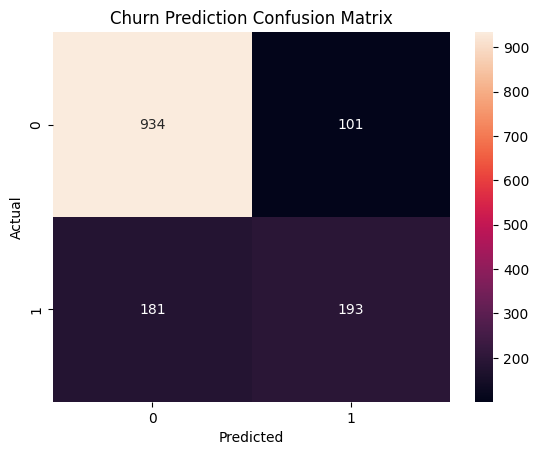

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Churn Prediction Confusion Matrix")

plt.show()

#### 8.9. Random Forest

In [46]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

#### 8.10. Random Forest Evaluation

In [47]:
print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

ROC-AUC: 0.8267883437960164
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 9. Model Evaluation & Comparison

#### 9.1. Model Comparison

In [48]:
logistic_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob)
}

In [49]:
#random forest

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf_prob)
}

In [50]:
model_comparison = pd.DataFrame([
    logistic_metrics,
    rf_metrics
])

model_comparison.round(2)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.80,0.66,0.52,0.58,0.85
1,Random Forest,0.79,0.64,0.48,0.55,0.83


#### 9.2. ROC Curve

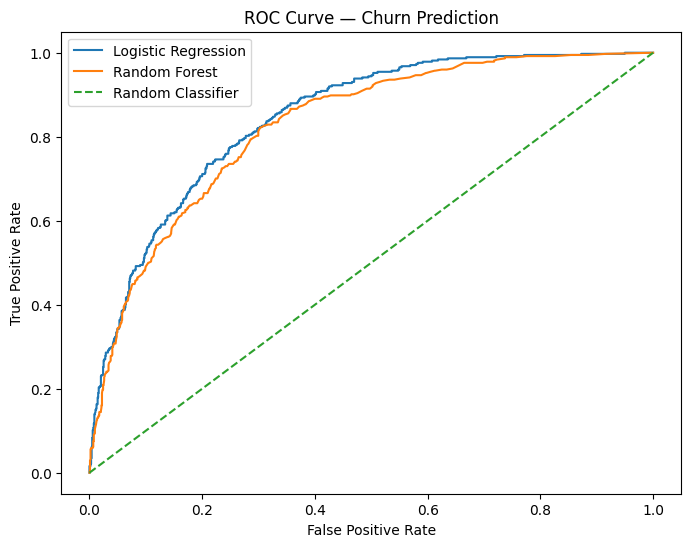

In [51]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Churn Prediction")

plt.legend()

plt.show()

#### 9.3. Precision-Recall Curve

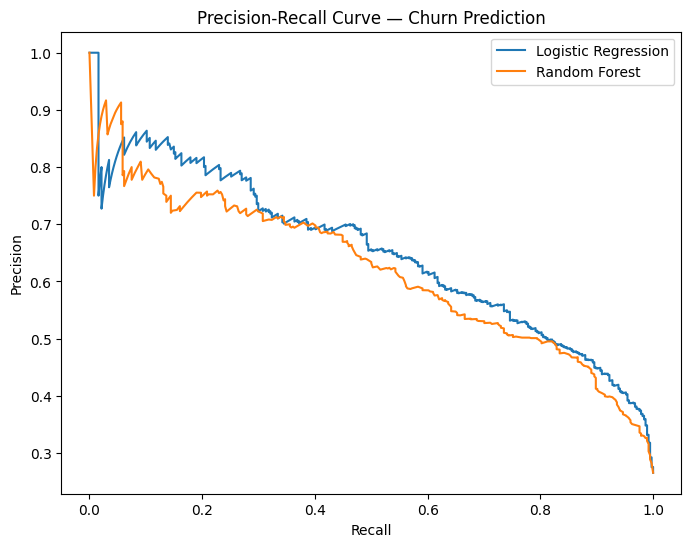

In [52]:
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    y_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_prob
)


plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve — Churn Prediction"
)

plt.legend()

plt.show()

## 10. Customer Risk Scoring

#### 10.1. Generating churn Probabilities

In [53]:
df_model = df.copy()

df_model["churn_probability"] = model.predict_proba(X)[:, 1]

#### 10.2. Creating Risk Segments

In [54]:
df_model["risk_segment"] = pd.cut(
    df_model["churn_probability"],
    bins=[0, 0.30, 0.60, 1],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

#### 10.3. Reviewing High-Risk Customers

In [55]:
df_model[
    [
        "customer_id",
        "churn_probability",
        "risk_segment"
    ]
].sort_values(
    "churn_probability",
    ascending=False
).head(20)

,customer_id,churn_probability,risk_segment
3380,5178-LMXOP,0.905907,High Risk
2208,7216-EWTRS,0.904316,High Risk
1976,9497-QCMMS,0.904074,High Risk
4800,9300-AGZNL,0.903550,High Risk
5989,5567-WSELE,0.901192,High Risk
3749,4424-TKOPW,0.901083,High Risk
6368,2720-WGKHP,0.900851,High Risk
1410,7024-OHCCK,0.898816,High Risk
3159,5150-ITWWB,0.897271,High Risk
997,1374-DMZUI,0.892824,High Risk


## 11. Revenue Risk & Customer Segmentation

#### 11.1. Expected Monthly Revenue Risk

In [56]:
df_model["expected_monthly_revenue_risk"] = (
    df_model["monthly_charges"]
    * df_model["churn_probability"]
)

In [57]:
expected_monthly_revenue_risk = (
    df_model["expected_monthly_revenue_risk"]
    .sum()
)

print(
    f"Expected Monthly Revenue Risk: "
    f"{expected_monthly_revenue_risk:,.2f}"
)

Expected Monthly Revenue Risk: 139,938.75


#### 11.2. Customer Value Segmentation

In [58]:
df_model["value_segment"] = np.where(
    df_model["monthly_charges"] >=
    df_model["monthly_charges"].median(),
    "High Value",
    "Low Value"
)

#### 11.3. Priority Segmentation

In [59]:
df_model["priority_segment"] = (
    df_model["value_segment"]
    + " / "
    + df_model["risk_segment"].astype(str)
)

#### 11.4. Priority Segment Analysis

In [60]:
priority_summary = (
    df_model
    .groupby("priority_segment")
    .agg(
        customers=("customer_id", "count"),
        avg_monthly_charge=("monthly_charges", "mean"),
        avg_churn_probability=("churn_probability", "mean"),
        actual_churn_rate=("churn_flag", "mean"),
        monthly_revenue=("monthly_charges", "sum"),
        expected_monthly_revenue_risk=(
            "expected_monthly_revenue_risk",
            "sum"
        )
    )
    .reset_index()
)

priority_summary["customer_percentage"] = (
    priority_summary["customers"]
    / priority_summary["customers"].sum()
    * 100
)

priority_summary["avg_churn_probability"] *= 100
priority_summary["actual_churn_rate"] *= 100

priority_summary = priority_summary.round(2)

priority_summary

,priority_segment,customers,avg_monthly_charge,avg_churn_probability,actual_churn_rate,monthly_revenue,expected_monthly_revenue_risk,customer_percentage
0,High Value / High Risk,804,86.58,73.09,73.01,69610.20,50862.13,11.42
1,High Value / Low Risk,1677,92.69,11.48,11.57,155437.75,18084.26,23.81
2,High Value / Medium Risk,1043,90.23,45.21,43.82,94113.95,42453.83,14.81
3,Low Value / High Risk,186,56.17,69.98,72.58,10447.60,7377.08,2.64
4,Low Value / Low Risk,2758,35.91,8.82,9.25,99031.65,9322.97,39.16
5,Low Value / Medium Risk,575,47.78,43.05,41.91,27475.45,11838.48,8.16


#### 11.5. High-Priority Customer List

In [61]:
priority_customers = (
    df_model[
        [
            "customer_id",
            "contract",
            "tenure",
            "monthly_charges",
            "churn_probability",
            "risk_segment",
            "value_segment",
            "priority_segment",
            "expected_monthly_revenue_risk"
        ]
    ]
    .sort_values(
        "expected_monthly_revenue_risk",
        ascending=False
    )
)

priority_customers.head(20)

,customer_id,contract,tenure,monthly_charges,churn_probability,risk_segment,value_segment,priority_segment,expected_monthly_revenue_risk
6894,1400-MMYXY,Month-to-month,3,105.90,0.885900,High Risk,High Value,High Value / High Risk,93.816857
5933,6496-SLWHQ,Month-to-month,3,105.00,0.882674,High Risk,High Value,High Value / High Risk,92.680797
2208,7216-EWTRS,Month-to-month,1,100.80,0.904316,High Risk,High Value,High Value / High Risk,91.155096
3956,4587-VVTOX,Month-to-month,6,105.30,0.856359,High Risk,High Value,High Value / High Risk,90.174560
6482,5419-JPRRN,Month-to-month,1,101.45,0.887481,High Risk,High Value,High Value / High Risk,90.034997
2797,6023-YEBUP,Month-to-month,3,100.95,0.882139,High Risk,High Value,High Value / High Risk,89.051895
171,1875-QIVME,Month-to-month,2,104.40,0.852627,High Risk,High Value,High Value / High Risk,89.014265
6232,9681-OXGVC,Month-to-month,5,100.50,0.873676,High Risk,High Value,High Value / High Risk,87.804428
3830,2656-TABEH,Month-to-month,4,100.20,0.865200,High Risk,High Value,High Value / High Risk,86.693038
1704,0107-YHINA,Month-to-month,1,99.75,0.867498,High Risk,High Value,High Value / High Risk,86.532896


## 12. Risk Validation

#### 12.1. Actual Churn by Risk Segment

In [62]:
risk_validation = (
    df_model
    .groupby("risk_segment", observed=True)
    .agg(
        customers=("customer_id", "count"),
        actual_churn_rate=("churn_flag", "mean"),
        avg_predicted_probability=("churn_probability", "mean")
    )
    .reset_index()
)

risk_validation["actual_churn_rate"] *= 100

risk_validation["avg_predicted_probability"] *= 100

risk_validation

,risk_segment,customers,actual_churn_rate,avg_predicted_probability
0,Low Risk,4435,10.124014,9.825999
1,Medium Risk,1618,43.139679,44.441195
2,High Risk,990,72.929293,72.505022


#### 12.2. Risk Decile Analysis

In [63]:
df_model["risk_decile"] = pd.qcut(
    df_model["churn_probability"],
    q=10,
    labels=False,
    duplicates="drop"
)

decile_analysis = (
    df_model
    .groupby("risk_decile")
    .agg(
        customers=("customer_id", "count"),
        avg_predicted_probability=("churn_probability", "mean"),
        actual_churn_rate=("churn_flag", "mean"),
        monthly_revenue=("monthly_charges", "sum")
    )
    .reset_index()
)

decile_analysis["avg_predicted_probability"] *= 100
decile_analysis["actual_churn_rate"] *= 100

decile_analysis

,risk_decile,customers,avg_predicted_probability,actual_churn_rate,monthly_revenue
0,0,705,0.876915,1.134752,24670.15
1,1,704,2.158800,1.988636,37107.40
2,2,704,4.434985,4.261364,43845.25
3,3,704,8.319419,9.375000,45647.50
4,4,705,14.851042,15.035461,47108.25
5,5,704,22.753757,22.301136,41830.20
6,6,704,32.593515,32.386364,50247.25
7,7,704,44.931845,42.045455,52488.80
8,8,704,58.895604,60.085227,55568.85
9,9,705,76.053928,76.737589,57602.95


#### 12.3. Predicted vs Actual Risk

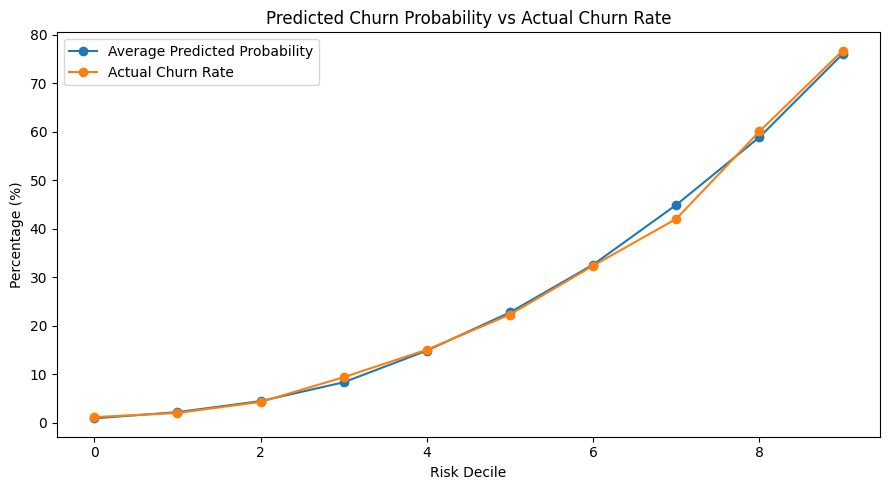

In [64]:
plt.figure(figsize=(9, 5))

plt.plot(
    decile_analysis["risk_decile"],
    decile_analysis["avg_predicted_probability"],
    marker="o",
    label="Average Predicted Probability"
)

plt.plot(
    decile_analysis["risk_decile"],
    decile_analysis["actual_churn_rate"],
    marker="o",
    label="Actual Churn Rate"
)

plt.xlabel("Risk Decile")
plt.ylabel("Percentage (%)")
plt.title("Predicted Churn Probability vs Actual Churn Rate")

plt.legend()
plt.tight_layout()
plt.show()

## 13. Model Interpretation

#### 13.1. Logistic Regression Coefficients

In [65]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coefficients["odds_ratio"] = np.exp(
    coefficients["coefficient"]
)

coefficients = coefficients.sort_values(
    "coefficient",
    ascending=False
)

coefficients.head(15)

,feature,coefficient,odds_ratio
10,internet_service_Fiber optic,1.244861,3.472451
9,multiple_lines_Yes,0.431691,1.539860
23,streaming_movies_Yes,0.424663,1.529075
21,streaming_tv_Yes,0.416557,1.516730
26,paperless_billing_Yes,0.389400,1.476095
28,payment_method_Electronic check,0.353053,1.423406
8,multiple_lines_No phone service,0.235312,1.265303
4,senior_citizen_Yes,0.154258,1.166792
17,device_protection_Yes,0.081981,1.085435
5,partner_Yes,0.042075,1.042973


#### 13.2. Features Associated With Higher Churn

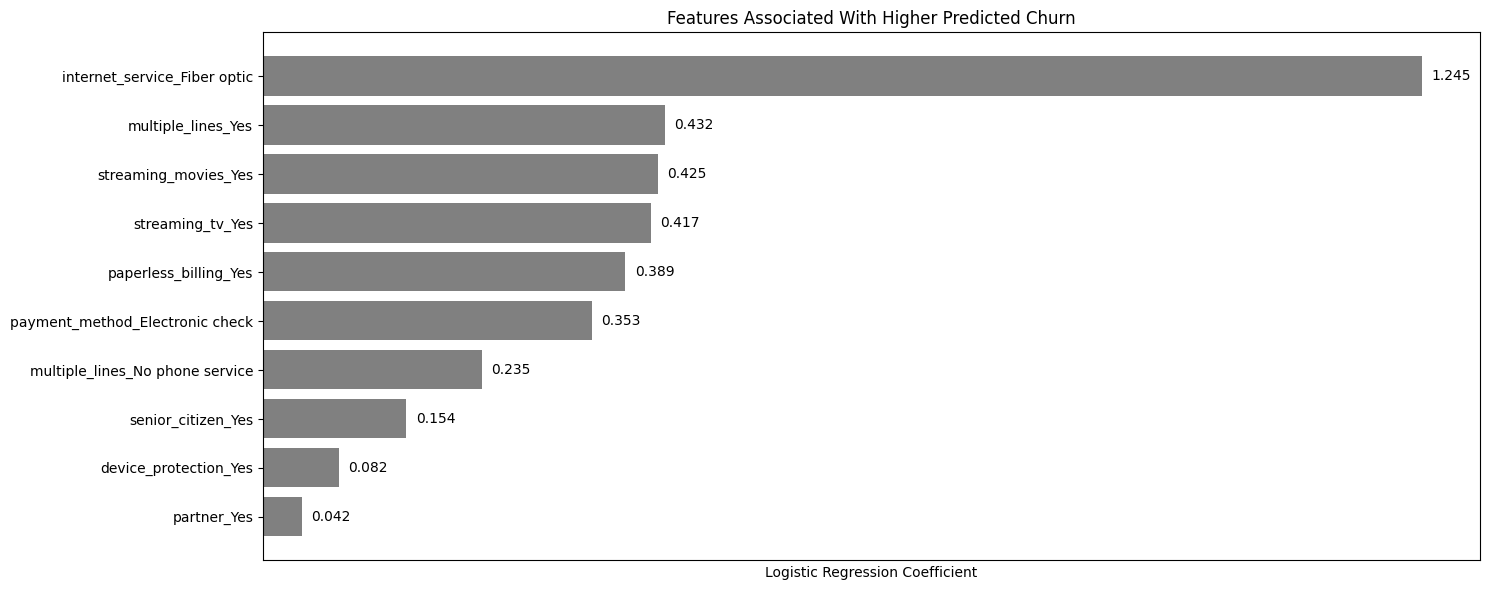

In [66]:
top_positive = (
    coefficients
    .head(10)
    .sort_values("coefficient")
)

plt.figure(figsize=(15, 6))

plt.barh(
    top_positive["feature"],
    top_positive["coefficient"],
    color="grey"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("")
plt.xticks([])

plt.title(
    "Features Associated With Higher Predicted Churn"
)
for i, value in enumerate(top_positive["coefficient"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.3f}",
        va="center",
        ha="left"
    )
plt.tight_layout()
plt.show()

#### 13.3. Features Associated With Lower Churn

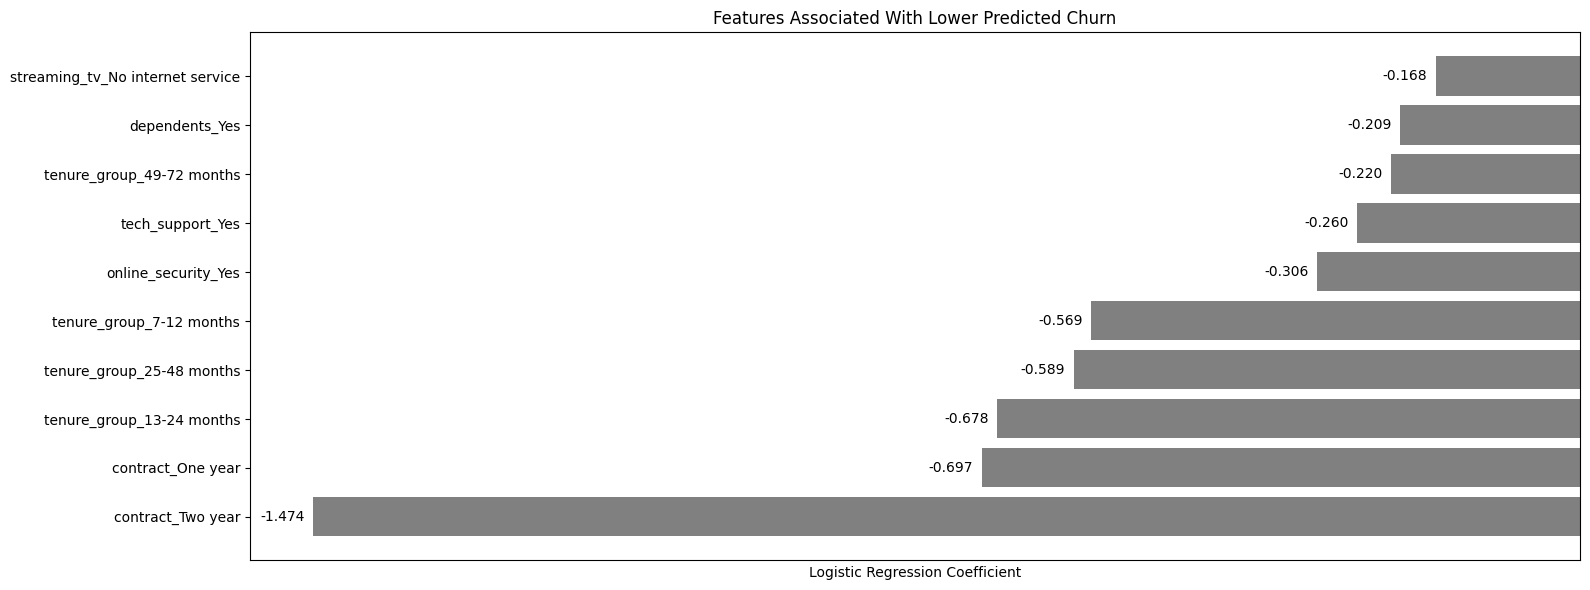

In [67]:
top_negative = (
    coefficients
    .tail(10)
    .sort_values("coefficient")
)

plt.figure(figsize=(16, 6))

plt.barh(
    top_negative["feature"],
    top_negative["coefficient"],
    color="grey"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("")
plt.xticks([])
for i, value in enumerate(top_negative["coefficient"]):
    plt.text(
        value - 0.01,
        i,
        f"{value:.3f}",
        va="center",
        ha="right"
    )
plt.title(
    "Features Associated With Lower Predicted Churn"
)

plt.tight_layout()
plt.show()

#### 13.4. Random Forest Feature Importance

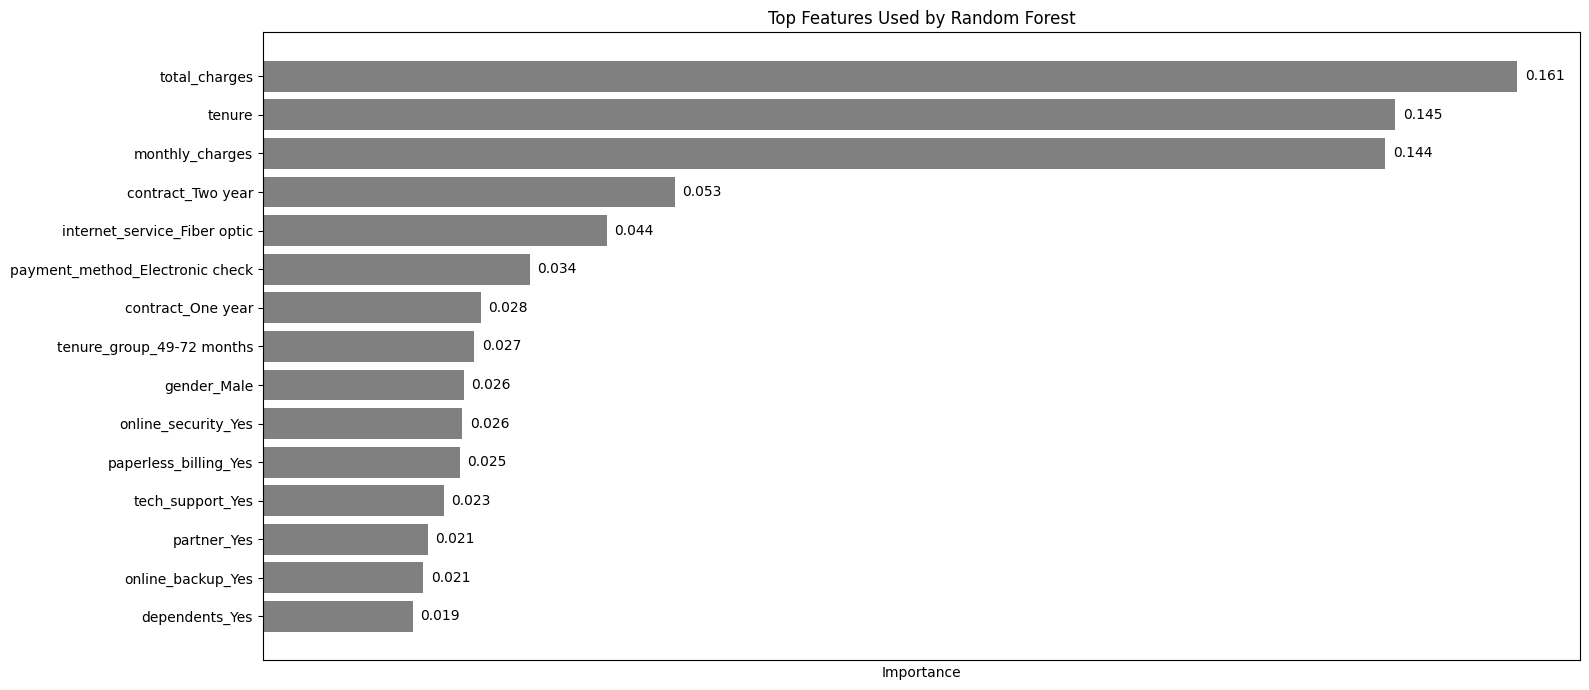

In [68]:
feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

top_features = (
    feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(16, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"],
    color="grey"
)

plt.xlabel("Importance")
plt.ylabel("")
plt.xticks([])
for i, value in enumerate(top_features["importance"]):
    plt.text(
        value + 0.001,
        i,
        f"{value:.3f}",
        va="center",
        ha="left"
    )

plt.title(
    "Top Features Used by Random Forest"
)

plt.tight_layout()
plt.show()

## 14. Visual Story

#### 14.1. Churn Distribution

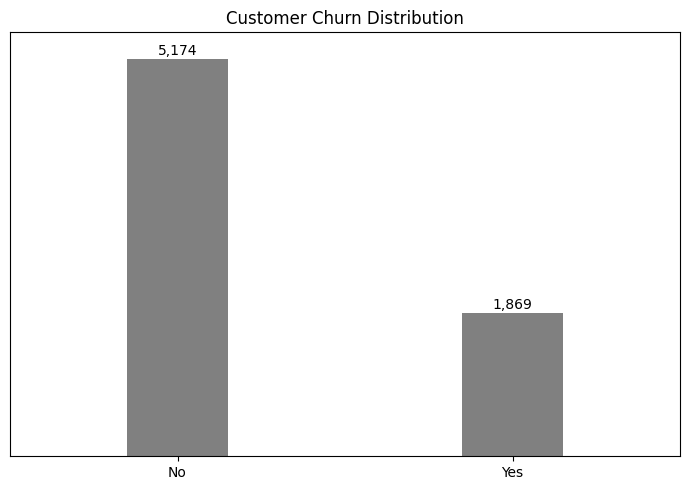

In [69]:
churn_counts = df["churn"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    color="grey",
    width=0.3
)

plt.title("Customer Churn Distribution")
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, value in enumerate(churn_counts.values):
    plt.text(
        i,
        value + 50,
        f"{value:,}",
        ha="center"
    )
plt.ylim(0, churn_counts.values.max() + 350)    
plt.tight_layout()
plt.show()

#### 14.2. Churn Rate by Contract

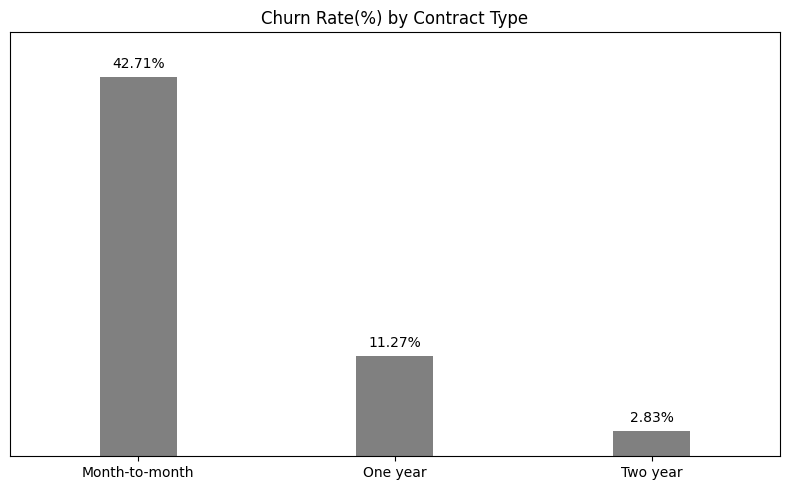

In [70]:
contract_churn = (
    df.groupby("contract")["churn_flag"]
    .mean()
    .mul(100)
    .reset_index(name="churn_rate")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="contract",
    y="churn_rate",
    color="grey",
    width=0.3
)

plt.title("Churn Rate(%) by Contract Type")
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, value in enumerate(contract_churn["churn_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )
plt.ylim(0, contract_churn["churn_rate"].max() + 5)
plt.tight_layout()
plt.show()

#### 14.3. Churn Rate by Tenure Group

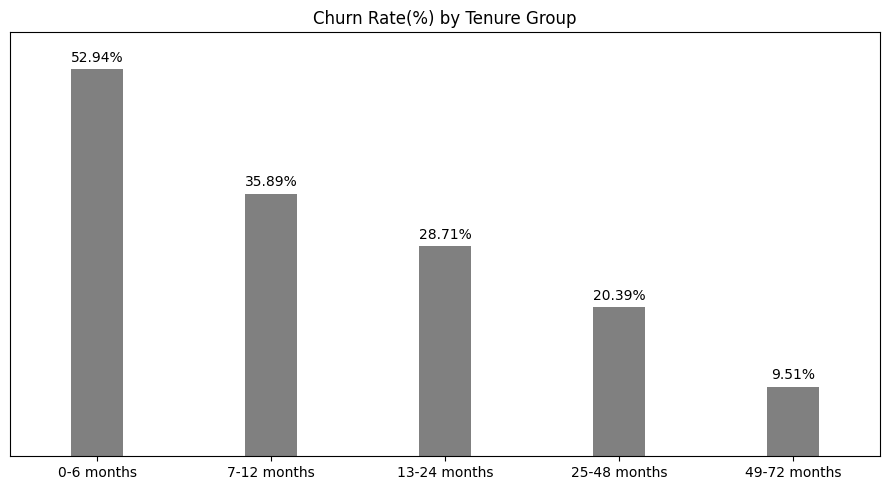

In [71]:
tenure_churn = (
    df.groupby("tenure_group", observed=True)["churn_flag"]
    .mean()
    .mul(100)
    .reset_index(name="churn_rate")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x="tenure_group",
    y="churn_rate",
    color="grey",
    width=0.3
)

plt.title("Churn Rate(%) by Tenure Group")
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, value in enumerate(tenure_churn["churn_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )
plt.ylim(0, tenure_churn["churn_rate"].max() + 5)    
plt.tight_layout()
plt.show()

#### 14.4. Churn Rate by Payment Method

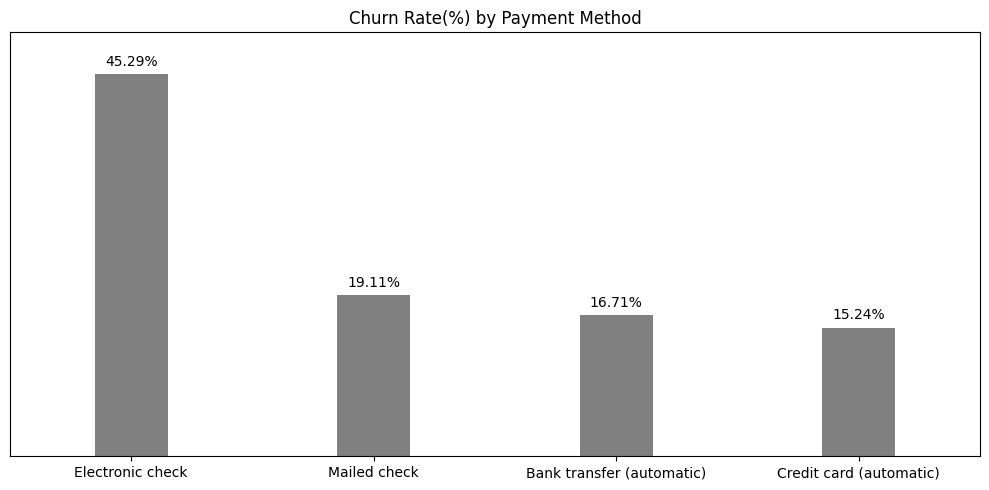

In [72]:
payment_churn = (
    df.groupby("payment_method")["churn_flag"]
    .mean()
    .mul(100)
    .reset_index(name="churn_rate")
    .sort_values("churn_rate", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn,
    x="payment_method",
    y="churn_rate",
    color="grey",
    width=0.3
)

plt.title("Churn Rate(%) by Payment Method")
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, value in enumerate(payment_churn["churn_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )
plt.ylim(0, payment_churn["churn_rate"].max() + 5)
plt.tight_layout()
plt.show()

#### 14.5. Monthly Charges by Churn Status

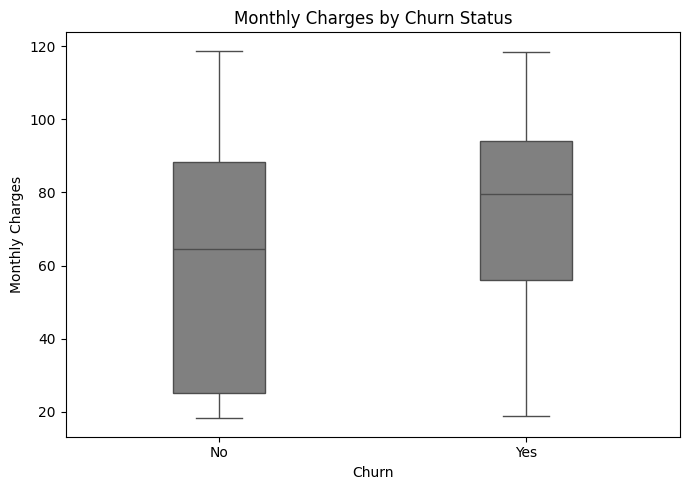

In [73]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="monthly_charges",
    color="grey",
    width=0.3
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

#### 14.6. Tenure vs Monthly Charges

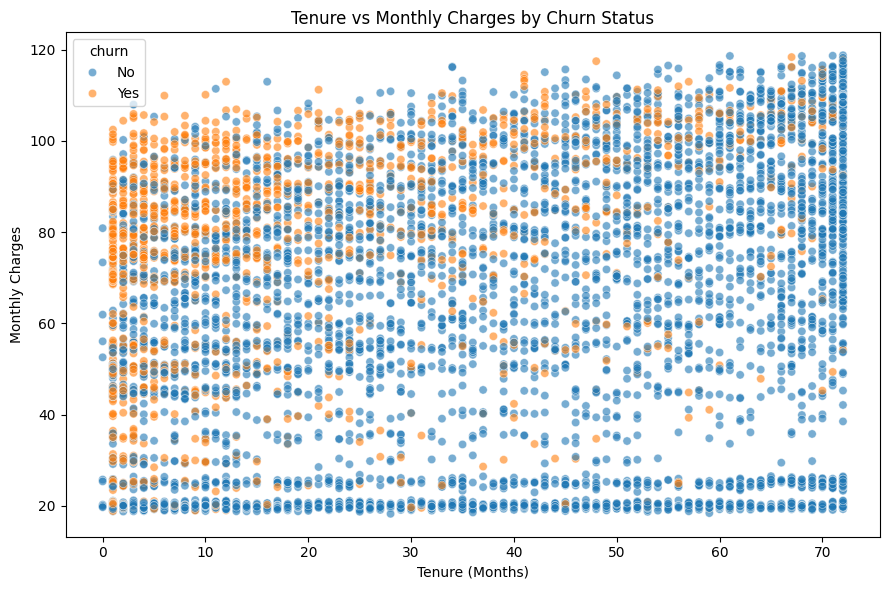

In [74]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="monthly_charges",
    hue="churn",
    alpha=0.6
)

plt.title("Tenure vs Monthly Charges by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

#### 14.7. Correlation Heatmap

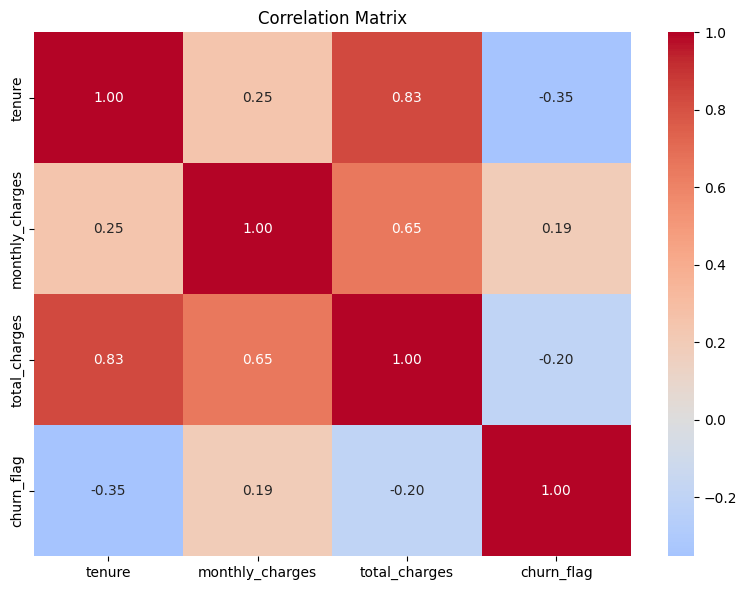

In [75]:
numeric_cols = [
    "tenure",
    "monthly_charges",
    "total_charges",
    "churn_flag"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

#### 14.8. Priority Segment Chart

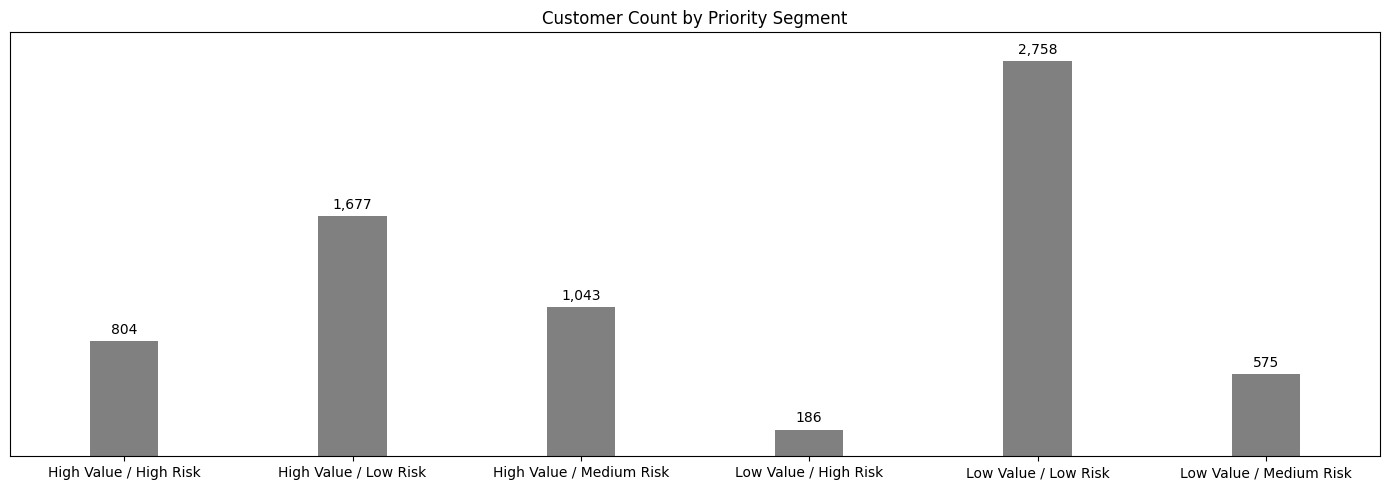

In [76]:
plt.figure(figsize=(14, 5))

sns.barplot(
    data=priority_summary,
    x="priority_segment",
    y="customers",
    color="grey",
    width=0.3
)

plt.title("Customer Count by Priority Segment")
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, value in enumerate(priority_summary["customers"]):
    plt.text(
        i,
        value + 50,
        f"{value:,}",
        ha="center"
    )
plt.ylim(0, priority_summary["customers"].max() + 200)    
plt.tight_layout()
plt.show()

#### 14.9. Churn Probability by Priority Segment

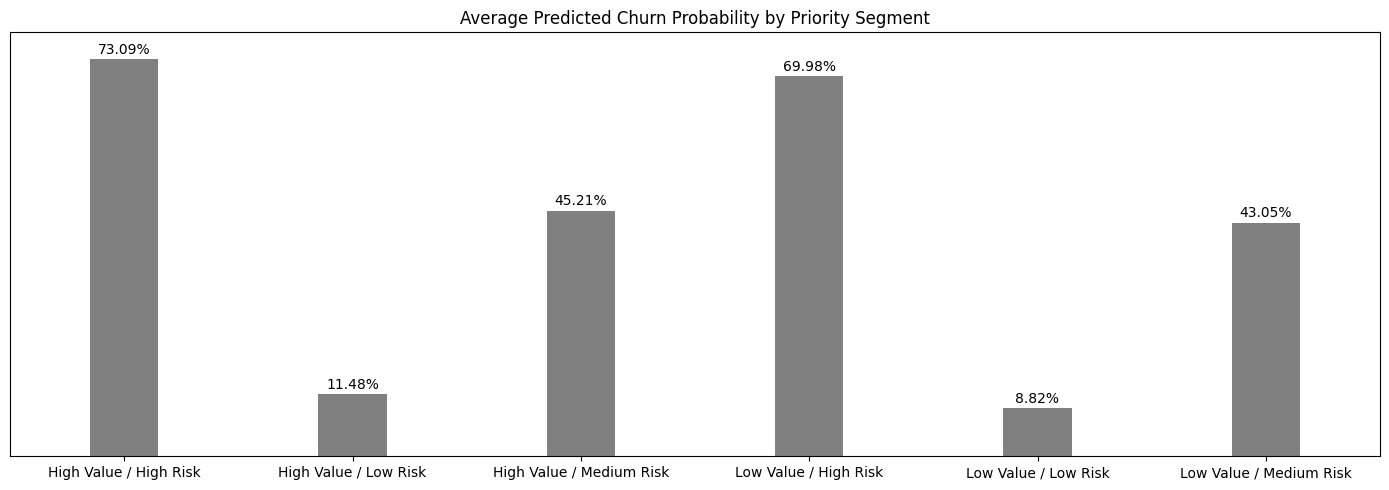

In [77]:
plt.figure(figsize=(14, 5))

sns.barplot(
    data=priority_summary,
    x="priority_segment",
    y="avg_churn_probability",
    color="grey",
    width=0.3
)

plt.title("Average Predicted Churn Probability by Priority Segment")
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, value in enumerate(priority_summary["avg_churn_probability"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )
plt.ylim(0, priority_summary["avg_churn_probability"].max() + 5)
plt.tight_layout()
plt.show()

#### 14.10. Revenue Risk by Priority Segment

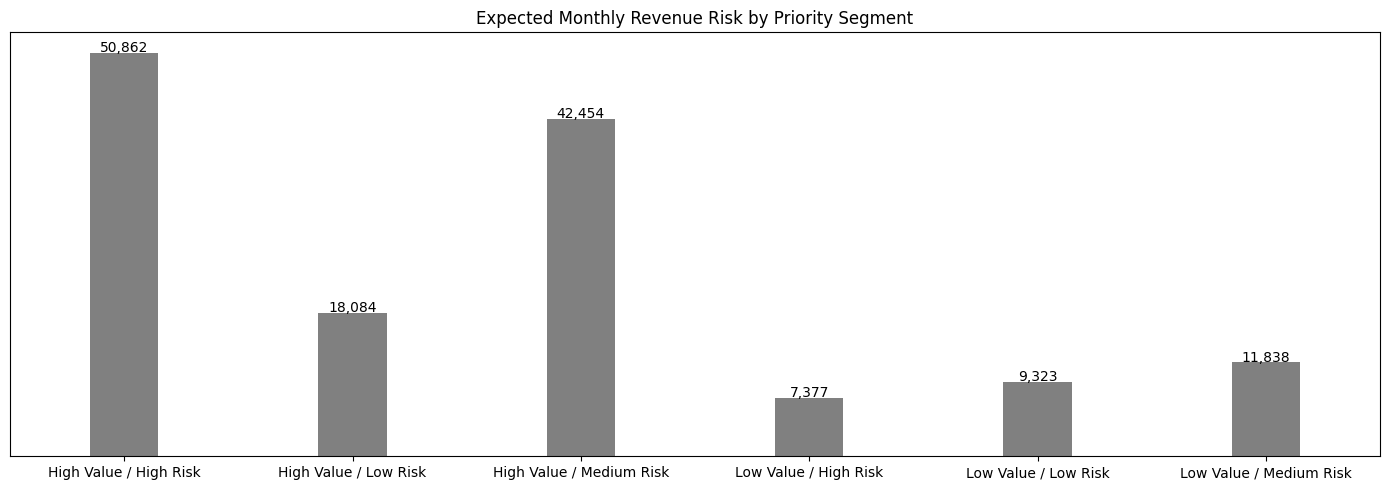

In [78]:
plt.figure(figsize=(14, 5))

sns.barplot(
    data=priority_summary,
    x="priority_segment",
    y="expected_monthly_revenue_risk",
    color="grey",
    width=0.3
)

plt.title("Expected Monthly Revenue Risk by Priority Segment")
plt.xlabel("")
plt.ylabel("")
plt.yticks([])
for i, value in enumerate(priority_summary["expected_monthly_revenue_risk"]):
    plt.text(
        i,
        value + 100,
        f"{value:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

#### 14.11. Actual Churn vs Predicted Risk

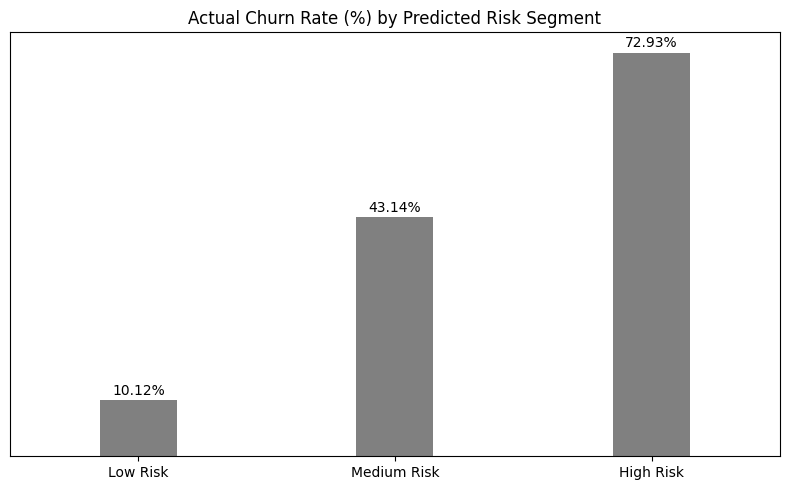

In [79]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_validation,
    x="risk_segment",
    y="actual_churn_rate",
    color="grey",
    width=0.3
)

plt.title("Actual Churn Rate (%) by Predicted Risk Segment")

plt.xlabel("")
plt.ylabel("")
plt.yticks([])

for i, value in enumerate(risk_validation["actual_churn_rate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 16. KPI Table

In [80]:
high_risk_customers = (
    df_model["risk_segment"]
    .eq("High Risk")
    .sum()
)

gross_monthly_revenue_exposure = (
    df_model.loc[
        df_model["risk_segment"] == "High Risk",
        "monthly_charges"
    ].sum()
)

expected_monthly_revenue_risk = (
    df_model["expected_monthly_revenue_risk"].sum()
)

final_kpis = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate (%)",
        "Average Tenure (Months)",
        "Average Monthly Charges",
        "High-Risk Customers",
        "High-Risk Customer (%)",
        "Gross Monthly Revenue Exposure",
        "Expected Monthly Revenue Risk"
    ],
    "Value": [
        total_customers,
        churned_customers,
        churn_rate,
        avg_tenure,
        avg_monthly_charges,
        high_risk_customers,
        high_risk_customers / total_customers * 100,
        gross_monthly_revenue_exposure,
        expected_monthly_revenue_risk
    ]
})

final_kpis.round(2)

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Overall Churn Rate (%),26.54
3,Average Tenure (Months),32.37
4,Average Monthly Charges,64.76
5,High-Risk Customers,990.00
6,High-Risk Customer (%),14.06
7,Gross Monthly Revenue Exposure,80057.80
8,Expected Monthly Revenue Risk,139938.75


## 17. Excel Report

In [81]:
output_path = r"C:\Users\narla\Downloads\customer churn\customer_churn_analysis.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:

    final_kpis.to_excel(writer, sheet_name="KPIs", index=False)

    priority_summary.to_excel(writer, sheet_name="Priority Segments", index=False)

    risk_validation.to_excel(writer, sheet_name="Risk Validation", index=False)

    model_comparison.to_excel(writer, sheet_name="Model Comparison", index=False)

    feature_importance.to_excel(writer, sheet_name="Feature Importance", index=False)

    coefficients.to_excel(writer, sheet_name="Logistic Coefficients", index=False)

    decile_analysis.to_excel(writer, sheet_name="Risk Deciles", index=False)

    priority_customers.head(100).to_excel(
        writer,
        sheet_name="Priority Customers",
        index=False
    )

    df_model.to_excel(
        writer,
        sheet_name="Customer Data",
        index=False
    )

print("Excel report saved successfully!")
print(output_path)

Excel report saved successfully!
C:\Users\narla\Downloads\customer churn\customer_churn_analysis.xlsx
